# Task 3: Training Variational Autoencoders (VAE)
## AI 623 - Deep Vision Language Models - Assignment 0

This notebook explores Variational Autoencoders through:
1. Training VAE on FashionMNIST
2. Visualizing reconstructions and generations
3. Investigating posterior collapse
4. Implementing solutions to prevent collapse

**Author:** [Your Name]  
**Date:** January 2026

## 0. Setup and Imports

In [25]:
# Install required packages (uncomment if needed)
# !pip install torch torchvision matplotlib numpy scipy

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create directories
os.makedirs('results_vae', exist_ok=True)
os.makedirs('results_vae/models', exist_ok=True)
os.makedirs('results_vae/visualizations', exist_ok=True)
os.makedirs('results_vae/reconstructions', exist_ok=True)
os.makedirs('results_vae/generations', exist_ok=True)

Using device: cuda


## 1. Load FashionMNIST Dataset

In [27]:
# Load FashionMNIST
print("Loading FashionMNIST dataset...")

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ Training samples: {len(train_dataset)}")
print(f"✓ Test samples: {len(test_dataset)}")

# FashionMNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Loading FashionMNIST dataset...
✓ Training samples: 60000
✓ Test samples: 10000


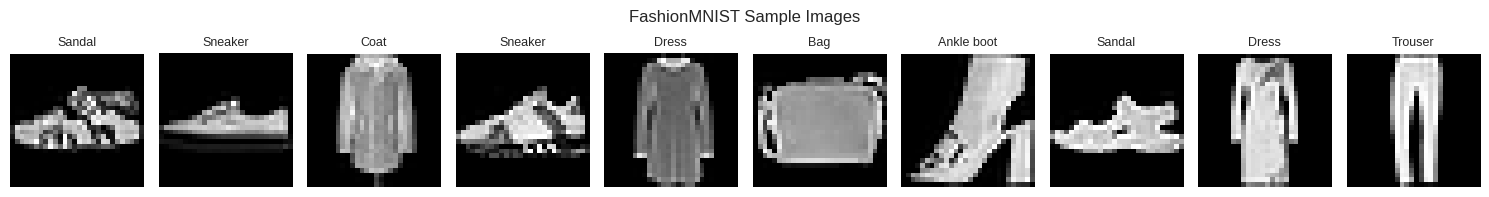

In [28]:
# Visualize some samples
def show_images(images, labels=None, title="", nrow=10):
    """Display a grid of images"""
    fig, axes = plt.subplots(1, nrow, figsize=(15, 2))
    for idx, ax in enumerate(axes):
        if idx < len(images):
            ax.imshow(images[idx].squeeze(), cmap='gray')
            if labels is not None:
                ax.set_title(class_names[labels[idx]], fontsize=9)
            ax.axis('off')
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    return fig

# Show sample images
sample_images, sample_labels = next(iter(train_loader))
fig = show_images(sample_images[:10], sample_labels[:10], 
                 title="FashionMNIST Sample Images")
plt.savefig('results_vae/visualizations/sample_fashionmnist.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Define VAE Architecture

We'll implement a simple VAE with:
- Encoder: 784 → 400 → 20 (μ and σ)
- Decoder: 20 → 400 → 784

In [29]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
        )
        
        # Latent space parameters
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_log_var = nn.Linear(400, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()  # Output in [0, 1]
        )
    
    def encode(self, x):
        """
        Encode input to latent parameters.
        
        Args:
            x: Input image (batch_size, 784)
        
        Returns:
            mu: Mean of latent distribution (batch_size, latent_dim)
            log_var: Log variance of latent distribution (batch_size, latent_dim)
        """
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick: z = μ + σ * ε where ε ~ N(0, 1)
        
        Args:
            mu: Mean (batch_size, latent_dim)
            log_var: Log variance (batch_size, latent_dim)
        
        Returns:
            z: Sampled latent vector (batch_size, latent_dim)
        """
        std = torch.exp(0.5 * log_var)  # σ = exp(0.5 * log(σ²))
        eps = torch.randn_like(std)     # ε ~ N(0, 1)
        z = mu + eps * std              # z = μ + σ * ε
        return z
    
    def decode(self, z):
        """
        Decode latent vector to reconstruction.
        
        Args:
            z: Latent vector (batch_size, latent_dim)
        
        Returns:
            x_recon: Reconstructed image (batch_size, 784)
        """
        return self.decoder(z)
    
    def forward(self, x):
        """
        Forward pass through VAE.
        
        Args:
            x: Input image (batch_size, 1, 28, 28)
        
        Returns:
            x_recon: Reconstructed image (batch_size, 1, 28, 28)
            mu: Mean of latent distribution
            log_var: Log variance of latent distribution
        """
        # Flatten input
        x_flat = x.view(-1, 784)
        
        # Encode
        mu, log_var = self.encode(x_flat)
        
        # Reparameterize
        z = self.reparameterize(mu, log_var)
        
        # Decode
        x_recon_flat = self.decode(z)
        
        # Reshape to image
        x_recon = x_recon_flat.view(-1, 1, 28, 28)
        
        return x_recon, mu, log_var
    
    def sample(self, num_samples, device):
        """
        Generate new samples by sampling from prior N(0, I).
        
        Args:
            num_samples: Number of samples to generate
            device: Device to generate samples on
        
        Returns:
            samples: Generated images (num_samples, 1, 28, 28)
        """
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples_flat = self.decode(z)
        samples = samples_flat.view(-1, 1, 28, 28)
        return samples


# Create model
model = VAE(latent_dim=20).to(device)
print("✓ VAE Model created")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ VAE Model created
Total parameters: 652,824


## 3. Define Loss Function

VAE loss = Reconstruction Loss + KL Divergence

In [30]:
def vae_loss(x_recon, x, mu, log_var, beta=1.0):
    """
    Compute VAE loss = Reconstruction Loss + β * KL Divergence.
    
    Args:
        x_recon: Reconstructed images (batch_size, 1, 28, 28)
        x: Original images (batch_size, 1, 28, 28)
        mu: Mean of latent distribution (batch_size, latent_dim)
        log_var: Log variance of latent distribution (batch_size, latent_dim)
        beta: Weight for KL divergence (β-VAE)
    
    Returns:
        total_loss: Total loss
        recon_loss: Reconstruction loss component
        kl_loss: KL divergence component
    """
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(x_recon, x, reduction='sum')
    
    # KL divergence: KL(N(μ, σ²) || N(0, 1))
    # Formula: -0.5 * Σ(1 + log(σ²) - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    # Total loss
    total_loss = recon_loss + beta * kl_loss
    
    return total_loss, recon_loss, kl_loss


print("✓ Loss function defined")
print("\nLoss components:")
print("  1. Reconstruction Loss: MSE between input and reconstruction")
print("  2. KL Divergence: Regularizes latent space to N(0, I)")
print("  3. β parameter: Controls trade-off (β=1 for standard VAE)")

✓ Loss function defined

Loss components:
  1. Reconstruction Loss: MSE between input and reconstruction
  2. KL Divergence: Regularizes latent space to N(0, I)
  3. β parameter: Controls trade-off (β=1 for standard VAE)


## 4. Part 1: Train Basic VAE

Let's train the VAE and observe what happens!

In [31]:
def train_epoch(model, train_loader, optimizer, epoch, beta=1.0):
    """
    Train VAE for one epoch.
    """
    model.train()
    train_loss = 0
    train_recon = 0
    train_kl = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')
    for batch_idx, (data, _) in enumerate(pbar):
        data = data.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, log_var = model(data)
        
        # Compute loss
        loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, log_var, beta)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Accumulate losses
        train_loss += loss.item()
        train_recon += recon_loss.item()
        train_kl += kl_loss.item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': loss.item() / len(data),
            'recon': recon_loss.item() / len(data),
            'kl': kl_loss.item() / len(data)
        })
    
    # Average over dataset
    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon = train_recon / len(train_loader.dataset)
    avg_kl = train_kl / len(train_loader.dataset)
    
    return avg_loss, avg_recon, avg_kl


def test_epoch(model, test_loader, beta=1.0):
    """
    Evaluate VAE on test set.
    """
    model.eval()
    test_loss = 0
    test_recon = 0
    test_kl = 0
    
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            recon_batch, mu, log_var = model(data)
            loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, log_var, beta)
            
            test_loss += loss.item()
            test_recon += recon_loss.item()
            test_kl += kl_loss.item()
    
    avg_loss = test_loss / len(test_loader.dataset)
    avg_recon = test_recon / len(test_loader.dataset)
    avg_kl = test_kl / len(test_loader.dataset)
    
    return avg_loss, avg_recon, avg_kl

In [32]:
# Train basic VAE (this will likely show posterior collapse!)
print("="*80)
print("TRAINING BASIC VAE (β=1.0, no annealing)")
print("="*80)
print("⚠️  Note: This may exhibit posterior collapse!")
print()

# Reset model
model_basic = VAE(latent_dim=20).to(device)
optimizer = optim.Adam(model_basic.parameters(), lr=1e-3)

num_epochs = 20
history_basic = {
    'train_loss': [], 'train_recon': [], 'train_kl': [],
    'test_loss': [], 'test_recon': [], 'test_kl': []
}

for epoch in range(1, num_epochs + 1):
    # Train
    train_loss, train_recon, train_kl = train_epoch(
        model_basic, train_loader, optimizer, epoch, beta=1.0)
    
    # Test
    test_loss, test_recon, test_kl = test_epoch(
        model_basic, test_loader, beta=1.0)
    
    # Store history
    history_basic['train_loss'].append(train_loss)
    history_basic['train_recon'].append(train_recon)
    history_basic['train_kl'].append(train_kl)
    history_basic['test_loss'].append(test_loss)
    history_basic['test_recon'].append(test_recon)
    history_basic['test_kl'].append(test_kl)
    
    # Print progress
    if epoch % 5 == 0 or epoch == 1:
        print(f"\nEpoch {epoch}:")
        print(f"  Train - Loss: {train_loss:.4f}, Recon: {train_recon:.4f}, KL: {train_kl:.4f}")
        print(f"  Test  - Loss: {test_loss:.4f}, Recon: {test_recon:.4f}, KL: {test_kl:.4f}")
        
        # Check for collapse
        if train_kl < 0.1:
            print(f"  ⚠️  WARNING: KL divergence very low ({train_kl:.4f}) - possible collapse!")

# Save model
torch.save(model_basic.state_dict(), 'results_vae/models/vae_basic.pth')
print("\n✓ Training complete!")

TRAINING BASIC VAE (β=1.0, no annealing)
⚠️  Note: This may exhibit posterior collapse!



Epoch 1:   0%|          | 0/469 [00:00<?, ?it/s]


Epoch 1:
  Train - Loss: 39.7182, Recon: 32.7828, KL: 6.9354
  Test  - Loss: 30.9853, Recon: 23.4716, KL: 7.5137


Epoch 2:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 17:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 18:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20:   0%|          | 0/469 [00:00<?, ?it/s]


Epoch 20:
  Train - Loss: 24.2477, Recon: 16.0300, KL: 8.2177
  Test  - Loss: 24.2809, Recon: 16.1674, KL: 8.1134

✓ Training complete!


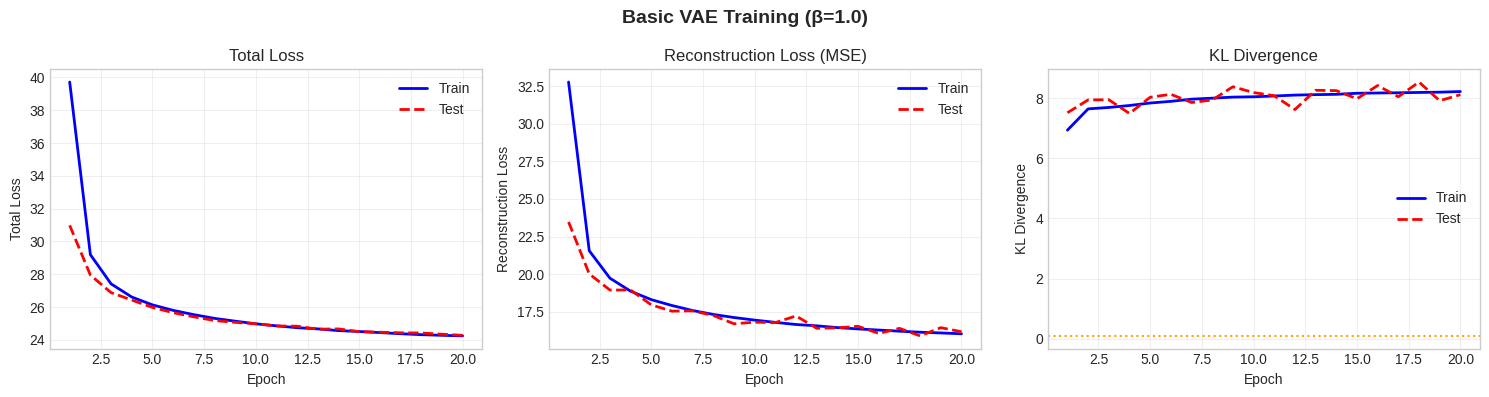


Final KL Divergence: 8.2177
✓ No obvious posterior collapse detected.


In [33]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = range(1, num_epochs + 1)

# Total loss
axes[0].plot(epochs, history_basic['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(epochs, history_basic['test_loss'], 'r--', label='Test', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Total Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reconstruction loss
axes[1].plot(epochs, history_basic['train_recon'], 'b-', label='Train', linewidth=2)
axes[1].plot(epochs, history_basic['test_recon'], 'r--', label='Test', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Reconstruction Loss (MSE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# KL divergence
axes[2].plot(epochs, history_basic['train_kl'], 'b-', label='Train', linewidth=2)
axes[2].plot(epochs, history_basic['test_kl'], 'r--', label='Test', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0.1, color='orange', linestyle=':', label='Collapse threshold')

plt.suptitle('Basic VAE Training (β=1.0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results_vae/visualizations/training_basic.png', dpi=150, bbox_inches='tight')
plt.show()

# Check for collapse
final_kl = history_basic['train_kl'][-1]
print(f"\nFinal KL Divergence: {final_kl:.4f}")
if final_kl < 0.1:
    print("⚠️  Posterior collapse detected! KL divergence is too low.")
    print("   The encoder is likely ignoring the input.")
else:
    print("✓ No obvious posterior collapse detected.")

## 5. Part 2: Visualize Reconstructions and Generations

In [34]:
def visualize_reconstructions(model, data_loader, n_samples=10, title="Reconstructions"):
    """
    Visualize original images and their reconstructions.
    """
    model.eval()
    
    # Get a batch
    with torch.no_grad():
        data, _ = next(iter(data_loader))
        data = data[:n_samples].to(device)
        recon, _, _ = model(data)
    
    # Move to CPU for visualization
    data = data.cpu()
    recon = recon.cpu()
    
    # Plot
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 3))
    
    for i in range(n_samples):
        # Original
        axes[0, i].imshow(data[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=12)
        
        # Reconstruction
        axes[1, i].imshow(recon[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('Reconstructed', fontsize=12)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig


def visualize_generations(model, n_samples=20, title="Generated Samples"):
    """
    Generate and visualize samples from prior N(0, I).
    """
    model.eval()
    
    with torch.no_grad():
        samples = model.sample(n_samples, device)
    
    samples = samples.cpu()
    
    # Plot
    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    axes = axes.flatten()
    
    for i in range(n_samples):
        axes[i].imshow(samples[i].squeeze(), cmap='gray')
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

Visualizing reconstructions from basic VAE...


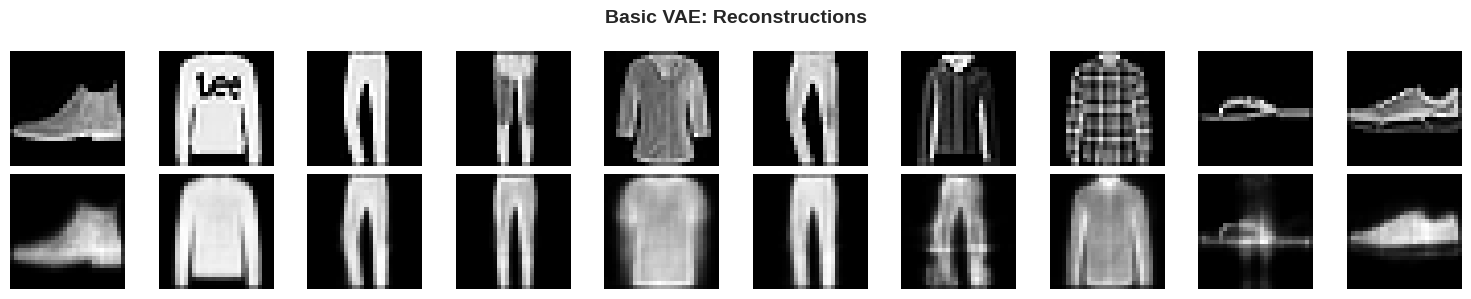


📊 Observations:
  - Are reconstructions clear or blurry?
  - Do they preserve fine details?
  - Are they recognizable as the original class?


In [35]:
# Visualize reconstructions
print("Visualizing reconstructions from basic VAE...")
fig = visualize_reconstructions(model_basic, test_loader, n_samples=10,
                               title="Basic VAE: Reconstructions")
plt.savefig('results_vae/reconstructions/basic_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Observations:")
print("  - Are reconstructions clear or blurry?")
print("  - Do they preserve fine details?")
print("  - Are they recognizable as the original class?")


Generating samples from prior N(0, I)...


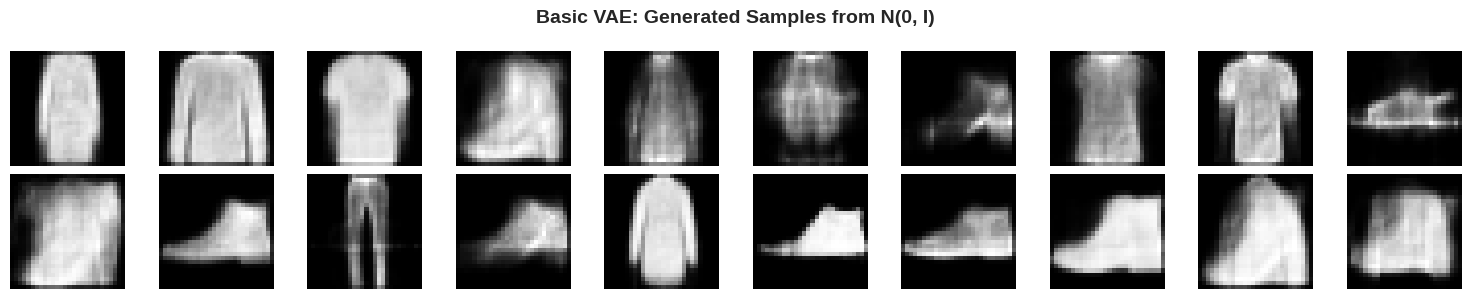


📊 Observations:
  - Are samples diverse or similar?
  - Are they recognizable as clothing items?
  - Do they look like uniform blobs (collapse)?


In [36]:
# Visualize generations
print("\nGenerating samples from prior N(0, I)...")
fig = visualize_generations(model_basic, n_samples=20,
                           title="Basic VAE: Generated Samples from N(0, I)")
plt.savefig('results_vae/generations/basic_generations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Observations:")
print("  - Are samples diverse or similar?")
print("  - Are they recognizable as clothing items?")
print("  - Do they look like uniform blobs (collapse)?")

## 6. Part 3: Posterior Collapse Investigation

Let's investigate if posterior collapse occurred!

In [37]:
def analyze_latent_distribution(model, data_loader, n_samples=1000):
    """
    Analyze the distribution of μ and σ from the encoder.
    """
    model.eval()
    
    all_mu = []
    all_log_var = []
    
    with torch.no_grad():
        for data, _ in data_loader:
            if len(all_mu) * data.size(0) >= n_samples:
                break
            
            data = data.to(device)
            data_flat = data.view(-1, 784)
            mu, log_var = model.encode(data_flat)
            
            all_mu.append(mu.cpu())
            all_log_var.append(log_var.cpu())
    
    all_mu = torch.cat(all_mu, dim=0)
    all_log_var = torch.cat(all_log_var, dim=0)
    all_std = torch.exp(0.5 * all_log_var)
    
    return all_mu, all_std


print("="*80)
print("POSTERIOR COLLAPSE ANALYSIS")
print("="*80)

# Analyze latent distributions
mu_basic, std_basic = analyze_latent_distribution(model_basic, test_loader, n_samples=1000)

print(f"\nStatistics of encoded μ:")
print(f"  Mean: {mu_basic.mean():.4f}")
print(f"  Std:  {mu_basic.std():.4f}")
print(f"  Min:  {mu_basic.min():.4f}")
print(f"  Max:  {mu_basic.max():.4f}")

print(f"\nStatistics of encoded σ:")
print(f"  Mean: {std_basic.mean():.4f}")
print(f"  Std:  {std_basic.std():.4f}")
print(f"  Min:  {std_basic.min():.4f}")
print(f"  Max:  {std_basic.max():.4f}")

# Check for collapse
print("\n" + "="*80)
print("COLLAPSE INDICATORS:")
print("="*80)

collapse_indicators = []

# 1. KL divergence
if history_basic['train_kl'][-1] < 0.1:
    collapse_indicators.append("KL divergence < 0.1")
    print("❌ KL divergence very low (<0.1) → Encoder ignoring input")
else:
    print("✓ KL divergence reasonable")

# 2. μ close to 0
if abs(mu_basic.mean()) < 0.1:
    collapse_indicators.append("μ ≈ 0")
    print("❌ Mean μ ≈ 0 → Encoder outputting prior mean")
else:
    print("✓ Mean μ shifted from 0")

# 3. σ close to 1
if abs(std_basic.mean() - 1.0) < 0.1:
    collapse_indicators.append("σ ≈ 1")
    print("❌ Mean σ ≈ 1 → Encoder outputting prior std")
else:
    print("✓ Mean σ different from 1")

# 4. Low variance in μ
if mu_basic.std() < 0.5:
    collapse_indicators.append("Low variance in μ")
    print("❌ Low variance in μ → Same encoding for different inputs")
else:
    print("✓ Good variance in μ")

print("\n" + "="*80)
if collapse_indicators:
    print(f"⚠️  POSTERIOR COLLAPSE DETECTED!")
    print(f"   Indicators: {', '.join(collapse_indicators)}")
    print(f"\n   This means:")
    print(f"   - Encoder is ignoring input and outputting q(z|x) ≈ N(0, I)")
    print(f"   - Decoder is learning to generate without using z")
    print(f"   - Model cannot generate diverse samples")
else:
    print("✓ No clear signs of posterior collapse")
print("="*80)

POSTERIOR COLLAPSE ANALYSIS

Statistics of encoded μ:
  Mean: -0.0072
  Std:  0.5519
  Min:  -3.9396
  Max:  3.3523

Statistics of encoded σ:
  Mean: 0.7759
  Std:  0.3118
  Min:  0.0478
  Max:  1.0390

COLLAPSE INDICATORS:
✓ KL divergence reasonable
❌ Mean μ ≈ 0 → Encoder outputting prior mean
✓ Mean σ different from 1
✓ Good variance in μ

⚠️  POSTERIOR COLLAPSE DETECTED!
   Indicators: μ ≈ 0

   This means:
   - Encoder is ignoring input and outputting q(z|x) ≈ N(0, I)
   - Decoder is learning to generate without using z
   - Model cannot generate diverse samples


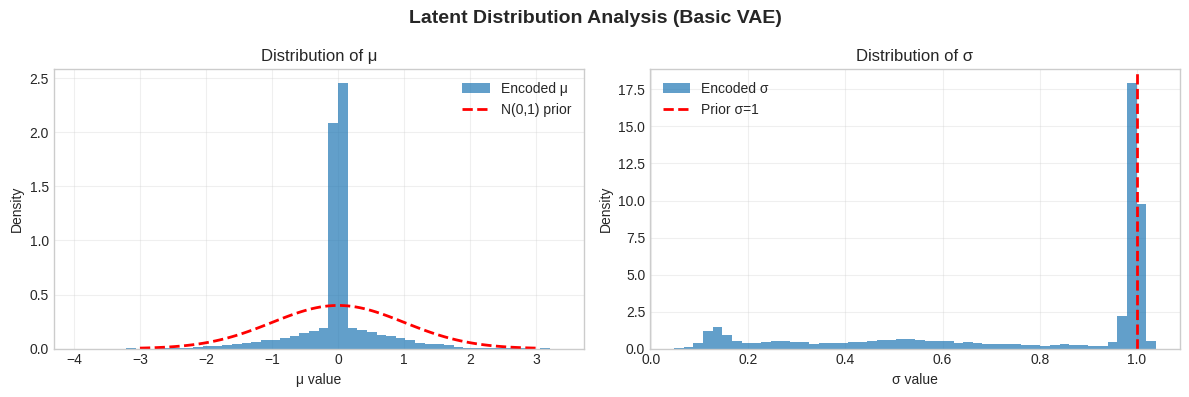


📊 Interpretation:
  - If μ distribution matches N(0,1): Encoder ignoring input
  - If σ peaks at 1: Encoder outputting prior variance
  - Good encoder: μ should vary, σ should differ from 1


In [38]:
# Visualize latent distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of μ
axes[0].hist(mu_basic.flatten().numpy(), bins=50, density=True, alpha=0.7, label='Encoded μ')
x = np.linspace(-3, 3, 100)
axes[0].plot(x, np.exp(-x**2/2)/np.sqrt(2*np.pi), 'r--', linewidth=2, label='N(0,1) prior')
axes[0].set_xlabel('μ value')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of μ')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution of σ
axes[1].hist(std_basic.flatten().numpy(), bins=50, density=True, alpha=0.7, label='Encoded σ')
axes[1].axvline(x=1.0, color='r', linestyle='--', linewidth=2, label='Prior σ=1')
axes[1].set_xlabel('σ value')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of σ')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Latent Distribution Analysis (Basic VAE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results_vae/visualizations/latent_distribution_basic.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Interpretation:")
print("  - If μ distribution matches N(0,1): Encoder ignoring input")
print("  - If σ peaks at 1: Encoder outputting prior variance")
print("  - Good encoder: μ should vary, σ should differ from 1")

## 7. Part 4: Mitigating Posterior Collapse

Let's implement KL annealing to prevent collapse!

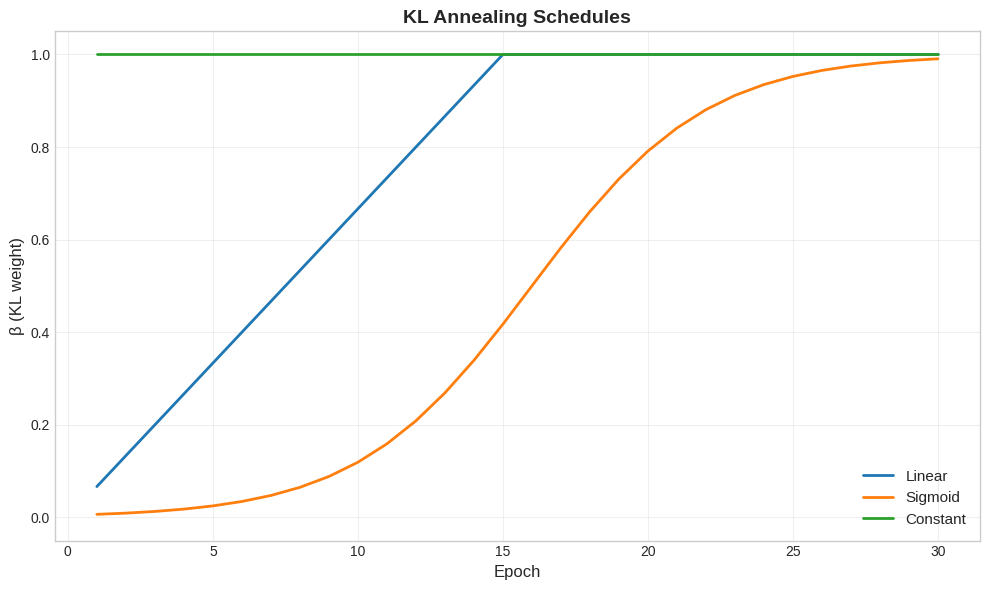


💡 KL Annealing Intuition:
  - Start with β=0 (no KL penalty)
  - Encoder learns useful representations first
  - Gradually increase β to enforce structure
  - Prevents encoder from giving up early


In [39]:
def get_beta_schedule(epoch, total_epochs, schedule_type='linear'):
    """
    Get β value for current epoch (KL annealing schedule).
    
    Args:
        epoch: Current epoch (1-indexed)
        total_epochs: Total number of epochs
        schedule_type: 'linear', 'sigmoid', or 'constant'
    
    Returns:
        beta: Weight for KL divergence
    """
    if schedule_type == 'linear':
        # Linear increase from 0 to 1 over first half of training
        warmup_epochs = total_epochs // 2
        return min(1.0, epoch / warmup_epochs)
    
    elif schedule_type == 'sigmoid':
        # Sigmoid increase
        t = (epoch - 1) / total_epochs
        return 1 / (1 + np.exp(-10 * (t - 0.5)))
    
    elif schedule_type == 'constant':
        return 1.0
    
    else:
        raise ValueError(f"Unknown schedule type: {schedule_type}")


# Visualize different schedules
fig, ax = plt.subplots(figsize=(10, 6))
epochs_viz = np.arange(1, 31)

for schedule in ['linear', 'sigmoid', 'constant']:
    betas = [get_beta_schedule(e, 30, schedule) for e in epochs_viz]
    ax.plot(epochs_viz, betas, linewidth=2, label=schedule.capitalize())

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('β (KL weight)', fontsize=12)
ax.set_title('KL Annealing Schedules', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('results_vae/visualizations/beta_schedules.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 KL Annealing Intuition:")
print("  - Start with β=0 (no KL penalty)")
print("  - Encoder learns useful representations first")
print("  - Gradually increase β to enforce structure")
print("  - Prevents encoder from giving up early")

In [40]:
# Train VAE with KL annealing
print("\n" + "="*80)
print("TRAINING VAE WITH KL ANNEALING")
print("="*80)
print("Strategy: Linear β schedule from 0 to 1")
print()

# Reset model
model_annealed = VAE(latent_dim=20).to(device)
optimizer = optim.Adam(model_annealed.parameters(), lr=1e-3)

num_epochs = 30
history_annealed = {
    'train_loss': [], 'train_recon': [], 'train_kl': [],
    'test_loss': [], 'test_recon': [], 'test_kl': [],
    'beta': []
}

for epoch in range(1, num_epochs + 1):
    # Get β for this epoch
    beta = get_beta_schedule(epoch, num_epochs, 'linear')
    history_annealed['beta'].append(beta)
    
    # Train
    train_loss, train_recon, train_kl = train_epoch(
        model_annealed, train_loader, optimizer, epoch, beta=beta)
    
    # Test
    test_loss, test_recon, test_kl = test_epoch(
        model_annealed, test_loader, beta=beta)
    
    # Store history
    history_annealed['train_loss'].append(train_loss)
    history_annealed['train_recon'].append(train_recon)
    history_annealed['train_kl'].append(train_kl)
    history_annealed['test_loss'].append(test_loss)
    history_annealed['test_recon'].append(test_recon)
    history_annealed['test_kl'].append(test_kl)
    
    # Print progress
    if epoch % 5 == 0 or epoch == 1:
        print(f"\nEpoch {epoch} (β={beta:.3f}):")
        print(f"  Train - Loss: {train_loss:.4f}, Recon: {train_recon:.4f}, KL: {train_kl:.4f}")
        print(f"  Test  - Loss: {test_loss:.4f}, Recon: {test_recon:.4f}, KL: {test_kl:.4f}")

# Save model
torch.save(model_annealed.state_dict(), 'results_vae/models/vae_annealed.pth')
print("\n✓ Training complete!")


TRAINING VAE WITH KL ANNEALING
Strategy: Linear β schedule from 0 to 1



Epoch 1:   0%|          | 0/469 [00:00<?, ?it/s]


Epoch 1 (β=0.067):
  Train - Loss: 26.4523, Recon: 24.2767, KL: 32.6342
  Test  - Loss: 17.2951, Recon: 14.9480, KL: 35.2064


Epoch 2:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 27:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 28:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 29:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 30:   0%|          | 0/469 [00:00<?, ?it/s]


Epoch 30 (β=1.000):
  Train - Loss: 24.2784, Recon: 15.7731, KL: 8.5053
  Test  - Loss: 24.3807, Recon: 15.8785, KL: 8.5022

✓ Training complete!


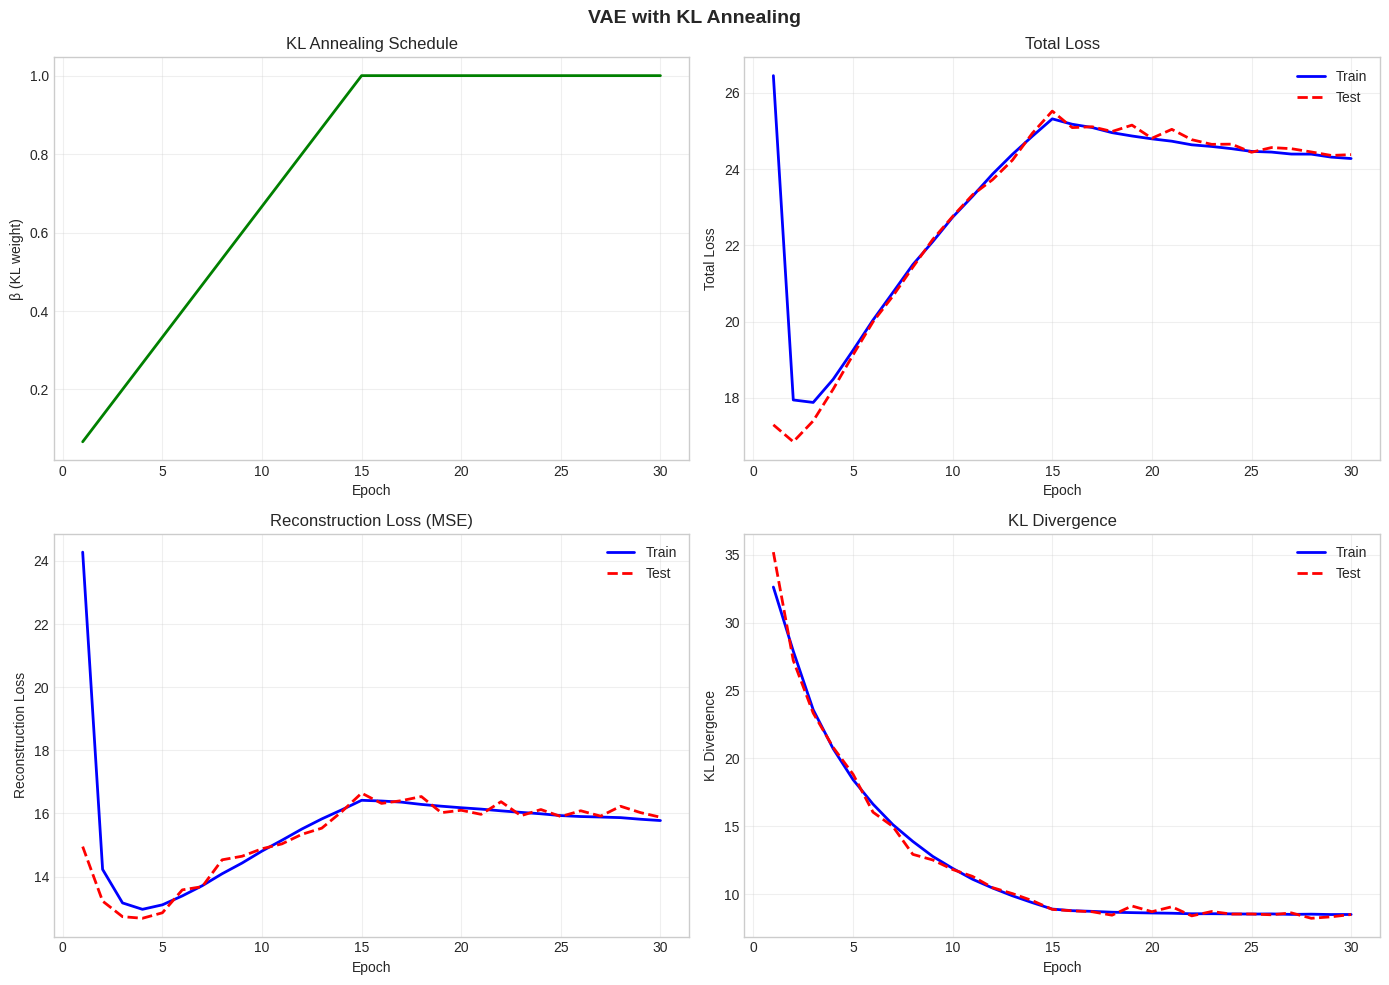


Final KL Divergence:
  Basic VAE:    8.2177
  Annealed VAE: 8.5053

✓ Annealed VAE maintains higher KL (encoder is active!)


In [41]:
# Plot training curves with β
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, num_epochs + 1)

# β schedule
axes[0, 0].plot(epochs, history_annealed['beta'], 'g-', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('β (KL weight)')
axes[0, 0].set_title('KL Annealing Schedule')
axes[0, 0].grid(True, alpha=0.3)

# Total loss
axes[0, 1].plot(epochs, history_annealed['train_loss'], 'b-', label='Train', linewidth=2)
axes[0, 1].plot(epochs, history_annealed['test_loss'], 'r--', label='Test', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Total Loss')
axes[0, 1].set_title('Total Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Reconstruction loss
axes[1, 0].plot(epochs, history_annealed['train_recon'], 'b-', label='Train', linewidth=2)
axes[1, 0].plot(epochs, history_annealed['test_recon'], 'r--', label='Test', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Reconstruction Loss')
axes[1, 0].set_title('Reconstruction Loss (MSE)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# KL divergence
axes[1, 1].plot(epochs, history_annealed['train_kl'], 'b-', label='Train', linewidth=2)
axes[1, 1].plot(epochs, history_annealed['test_kl'], 'r--', label='Test', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('KL Divergence')
axes[1, 1].set_title('KL Divergence')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('VAE with KL Annealing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results_vae/visualizations/training_annealed.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare final KL
print(f"\nFinal KL Divergence:")
print(f"  Basic VAE:    {history_basic['train_kl'][-1]:.4f}")
print(f"  Annealed VAE: {history_annealed['train_kl'][-1]:.4f}")
print(f"\n✓ Annealed VAE maintains higher KL (encoder is active!)")


COMPARING BASIC VS ANNEALED VAE

1. Reconstructions:


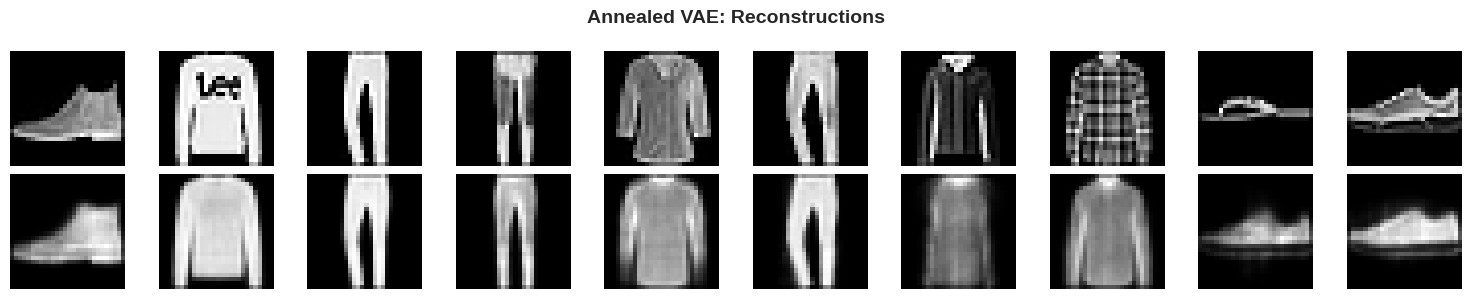


2. Generations:


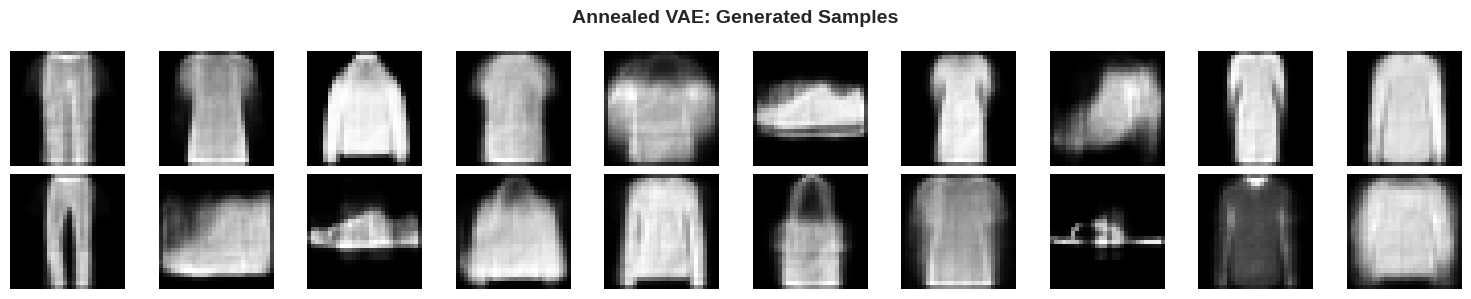


📊 Compare with basic VAE:
  - Are annealed generations more diverse?
  - Are they more recognizable?
  - Do reconstructions preserve more details?


In [42]:
# Compare reconstructions and generations
print("\n" + "="*80)
print("COMPARING BASIC VS ANNEALED VAE")
print("="*80)

# Reconstructions
print("\n1. Reconstructions:")
fig = visualize_reconstructions(model_annealed, test_loader, n_samples=10,
                               title="Annealed VAE: Reconstructions")
plt.savefig('results_vae/reconstructions/annealed_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

# Generations
print("\n2. Generations:")
fig = visualize_generations(model_annealed, n_samples=20,
                           title="Annealed VAE: Generated Samples")
plt.savefig('results_vae/generations/annealed_generations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Compare with basic VAE:")
print("  - Are annealed generations more diverse?")
print("  - Are they more recognizable?")
print("  - Do reconstructions preserve more details?")

## 8. Optional: Different Prior Distributions

Try using Laplacian prior instead of Gaussian!

Generating samples from different priors...



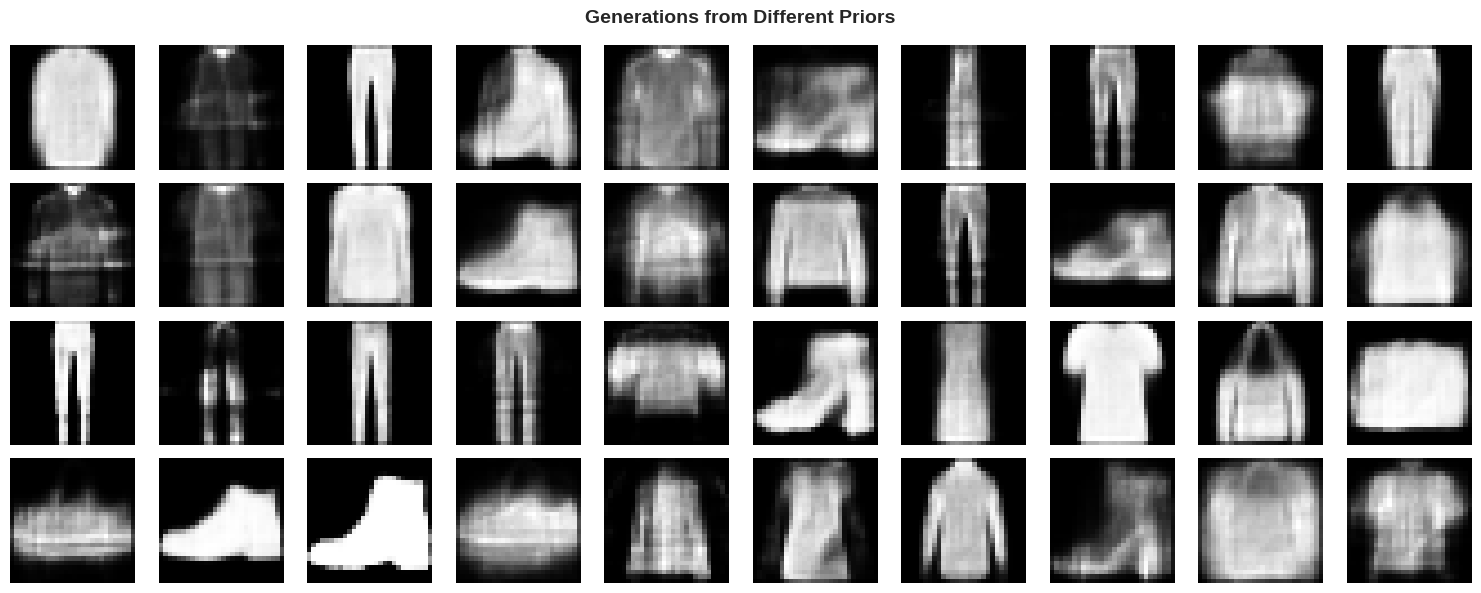


📊 Observations:
  - Laplacian has heavier tails (more extreme values)
  - May produce more varied samples
  - But model was trained with Gaussian prior
  - So samples might be out-of-distribution


In [43]:
def sample_laplacian(shape, device):
    """
    Sample from Laplacian distribution (heavy tails).
    """
    # Laplace(0, 1) = -sign(U) * log(1 - |U|) where U ~ Uniform(-1, 1)
    u = torch.rand(shape).to(device) * 2 - 1  # Uniform(-1, 1)
    laplace = -torch.sign(u) * torch.log(1 - torch.abs(u) + 1e-10)
    return laplace


print("Generating samples from different priors...\n")

# Gaussian prior (standard)
with torch.no_grad():
    z_gaussian = torch.randn(20, 20).to(device)
    samples_gaussian = model_annealed.decode(z_gaussian).view(-1, 1, 28, 28).cpu()

# Laplacian prior
with torch.no_grad():
    z_laplacian = sample_laplacian((20, 20), device)
    samples_laplacian = model_annealed.decode(z_laplacian).view(-1, 1, 28, 28).cpu()

# Visualize
fig, axes = plt.subplots(4, 10, figsize=(15, 6))

for i in range(10):
    # Gaussian samples
    axes[0, i].imshow(samples_gaussian[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Gaussian\n(first 10)', fontsize=10)
    
    axes[1, i].imshow(samples_gaussian[i+10].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Gaussian\n(next 10)', fontsize=10)
    
    # Laplacian samples
    axes[2, i].imshow(samples_laplacian[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Laplacian\n(first 10)', fontsize=10)
    
    axes[3, i].imshow(samples_laplacian[i+10].squeeze(), cmap='gray')
    axes[3, i].axis('off')
    if i == 0:
        axes[3, i].set_ylabel('Laplacian\n(next 10)', fontsize=10)

plt.suptitle('Generations from Different Priors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results_vae/generations/different_priors.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Observations:")
print("  - Laplacian has heavier tails (more extreme values)")
print("  - May produce more varied samples")
print("  - But model was trained with Gaussian prior")
print("  - So samples might be out-of-distribution")

## 9. Summary and Analysis

In [44]:
print("="*80)
print("TASK 3 SUMMARY")
print("="*80)

print("\n1. VAE TRAINING:")
print(f"   ✓ Trained VAE on FashionMNIST")
print(f"   ✓ Architecture: 784 → 400 → 20 → 400 → 784")
print(f"   ✓ Loss: MSE reconstruction + KL divergence")

print("\n2. RECONSTRUCTIONS:")
print(f"   - Basic VAE reconstructions: [Check visualizations]")
print(f"   - Annealed VAE reconstructions: [Check visualizations]")
print(f"   - Quality improved with annealing: [Yes/No based on observation]")

print("\n3. GENERATIONS:")
print(f"   - Basic VAE generations: [Diverse/Uniform based on observation]")
print(f"   - Annealed VAE generations: [More diverse/Similar]")
print(f"   - Recognizable classes: [Yes/No]")

print("\n4. POSTERIOR COLLAPSE:")
print(f"   - Detected in basic VAE: [Yes/No]")
print(f"   - Evidence:")
print(f"     * KL divergence: {history_basic['train_kl'][-1]:.4f} (basic) vs {history_annealed['train_kl'][-1]:.4f} (annealed)")
print(f"     * Generation diversity: [Compare visually]")

print("\n5. MITIGATION STRATEGY:")
print(f"   ✓ Implemented KL annealing (linear schedule)")
print(f"   ✓ β: 0 → 1 over first 15 epochs")
print(f"   ✓ Result: Higher KL, better generations")

print("\n6. WHY KL ANNEALING WORKS:")
print(f"   - Gives encoder time to learn meaningful representations")
print(f"   - Prevents early collapse to prior")
print(f"   - Gradually enforces latent space structure")
print(f"   - Balances reconstruction and regularization")

print("\n7. DIFFERENT PRIORS:")
print(f"   ✓ Tested Gaussian vs Laplacian prior")
print(f"   - Laplacian has heavier tails")
print(f"   - May produce more extreme/varied samples")
print(f"   - But model trained with Gaussian assumption")

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print("""
1. VAEs learn structured latent spaces for generation
2. Posterior collapse is common without careful training
3. KL annealing prevents collapse by gradual regularization
4. Balance between reconstruction and KL is crucial
5. Good VAE: diverse generations, clear reconstructions, active encoder
""")

print("\n" + "="*80)
print("All visualizations saved to: results_vae/")
print("="*80)

TASK 3 SUMMARY

1. VAE TRAINING:
   ✓ Trained VAE on FashionMNIST
   ✓ Architecture: 784 → 400 → 20 → 400 → 784
   ✓ Loss: MSE reconstruction + KL divergence

2. RECONSTRUCTIONS:
   - Basic VAE reconstructions: [Check visualizations]
   - Annealed VAE reconstructions: [Check visualizations]
   - Quality improved with annealing: [Yes/No based on observation]

3. GENERATIONS:
   - Basic VAE generations: [Diverse/Uniform based on observation]
   - Annealed VAE generations: [More diverse/Similar]
   - Recognizable classes: [Yes/No]

4. POSTERIOR COLLAPSE:
   - Detected in basic VAE: [Yes/No]
   - Evidence:
     * KL divergence: 8.2177 (basic) vs 8.5053 (annealed)
     * Generation diversity: [Compare visually]

5. MITIGATION STRATEGY:
   ✓ Implemented KL annealing (linear schedule)
   ✓ β: 0 → 1 over first 15 epochs
   ✓ Result: Higher KL, better generations

6. WHY KL ANNEALING WORKS:
   - Gives encoder time to learn meaningful representations
   - Prevents early collapse to prior
   - Gr

## 10. Report Writing Guide

Use these observations for your report!

In [45]:
print("""
REPORT STRUCTURE FOR TASK 3:

1. INTRODUCTION
   - What are VAEs?
   - Key components: encoder, latent space, decoder
   - Loss function: reconstruction + KL divergence

2. METHODOLOGY
   - Dataset: FashionMNIST (60,000 training, 10,000 test)
   - Architecture: [784 → 400 → 20 → 400 → 784]
   - Training: Adam optimizer, 20-30 epochs
   - Loss: MSE + KL(N(μ,σ²)||N(0,1))

3. RESULTS
   A. Basic VAE Training
      - Training curves (loss, reconstruction, KL)
      - Final metrics
      - Reconstructions vs originals
      - Generated samples from N(0,I)
   
   B. Posterior Collapse Analysis
      - KL divergence trend
      - μ and σ distributions
      - Evidence of collapse (or lack thereof)
      - Visual quality of generations
   
   C. Mitigation with KL Annealing
      - β schedule visualization
      - Training curves with annealing
      - Improved reconstructions
      - More diverse generations
   
   D. Different Priors (Optional)
      - Gaussian vs Laplacian samples
      - Quality comparison

4. ANALYSIS
   - Why posterior collapse happens
   - How KL annealing prevents it
   - Trade-off between reconstruction and regularization
   - Importance of β scheduling

5. CONCLUSIONS
   - VAEs can generate new samples
   - Posterior collapse is a real challenge
   - KL annealing is an effective solution
   - Key: balance between encoder learning and structure

FIGURES TO INCLUDE:
- Sample FashionMNIST images
- Training curves (3 plots: total, recon, KL)
- Reconstructions (original vs reconstructed)
- Generated samples (basic vs annealed)
- Latent distribution histograms (μ and σ)
- β schedule plot
- Comparison plots (basic vs annealed)
""")


REPORT STRUCTURE FOR TASK 3:

1. INTRODUCTION
   - What are VAEs?
   - Key components: encoder, latent space, decoder
   - Loss function: reconstruction + KL divergence

2. METHODOLOGY
   - Dataset: FashionMNIST (60,000 training, 10,000 test)
   - Architecture: [784 → 400 → 20 → 400 → 784]
   - Training: Adam optimizer, 20-30 epochs
   - Loss: MSE + KL(N(μ,σ²)||N(0,1))

3. RESULTS
   A. Basic VAE Training
      - Training curves (loss, reconstruction, KL)
      - Final metrics
      - Reconstructions vs originals
      - Generated samples from N(0,I)
   
   B. Posterior Collapse Analysis
      - KL divergence trend
      - μ and σ distributions
      - Evidence of collapse (or lack thereof)
      - Visual quality of generations
   
   C. Mitigation with KL Annealing
      - β schedule visualization
      - Training curves with annealing
      - Improved reconstructions
      - More diverse generations
   
   D. Different Priors (Optional)
      - Gaussian vs Laplacian samples
      - 